# 支持向量机SVM

视频：B站迪哥AI课堂：讲解清晰，大框架好
B站学弱猹：主数学推导




支持向量机（Support Vector Machine, SVM）：**硬间隔（理想状态） $\rightarrow$ 软间隔（现实妥协） $\rightarrow$ 核函数（维度升华）**。

---

### 一、 核心思想与起点

SVM 的核心目标非常纯粹：**在空间中找到一个超平面（Hyperplane），把不同类别的样本分开，并且让这个超平面距离最近的样本点（支持向量）越远越好。**
因为距离越远，分类的“容错率”越高，模型的泛化能力越强。

超平面的方程定义为：$w^T x + b = 0$
其中，$w$ 是法向量（决定方向），$b$ 是截距（决定平移）。

---

### 二、 阶段一：硬间隔 SVM (Hard Margin) —— 绝对严苛的线性切分

**适用场景**：数据是**绝对线性可分**的（一条直线或一个平面能完美分开两类，没有任何交集）。
**核心逻辑**：不仅要全部分对，而且离分类边界最近的点（支持向量），到边界的距离（Margin）必须最大化。几何上，Margin 的宽度等于 $\frac{2}{\|w\|}$。最大化 Margin 等价于最小化 $\|w\|^2$。（下图把点带入决策边界的方程及可得到Margin的宽度表示）
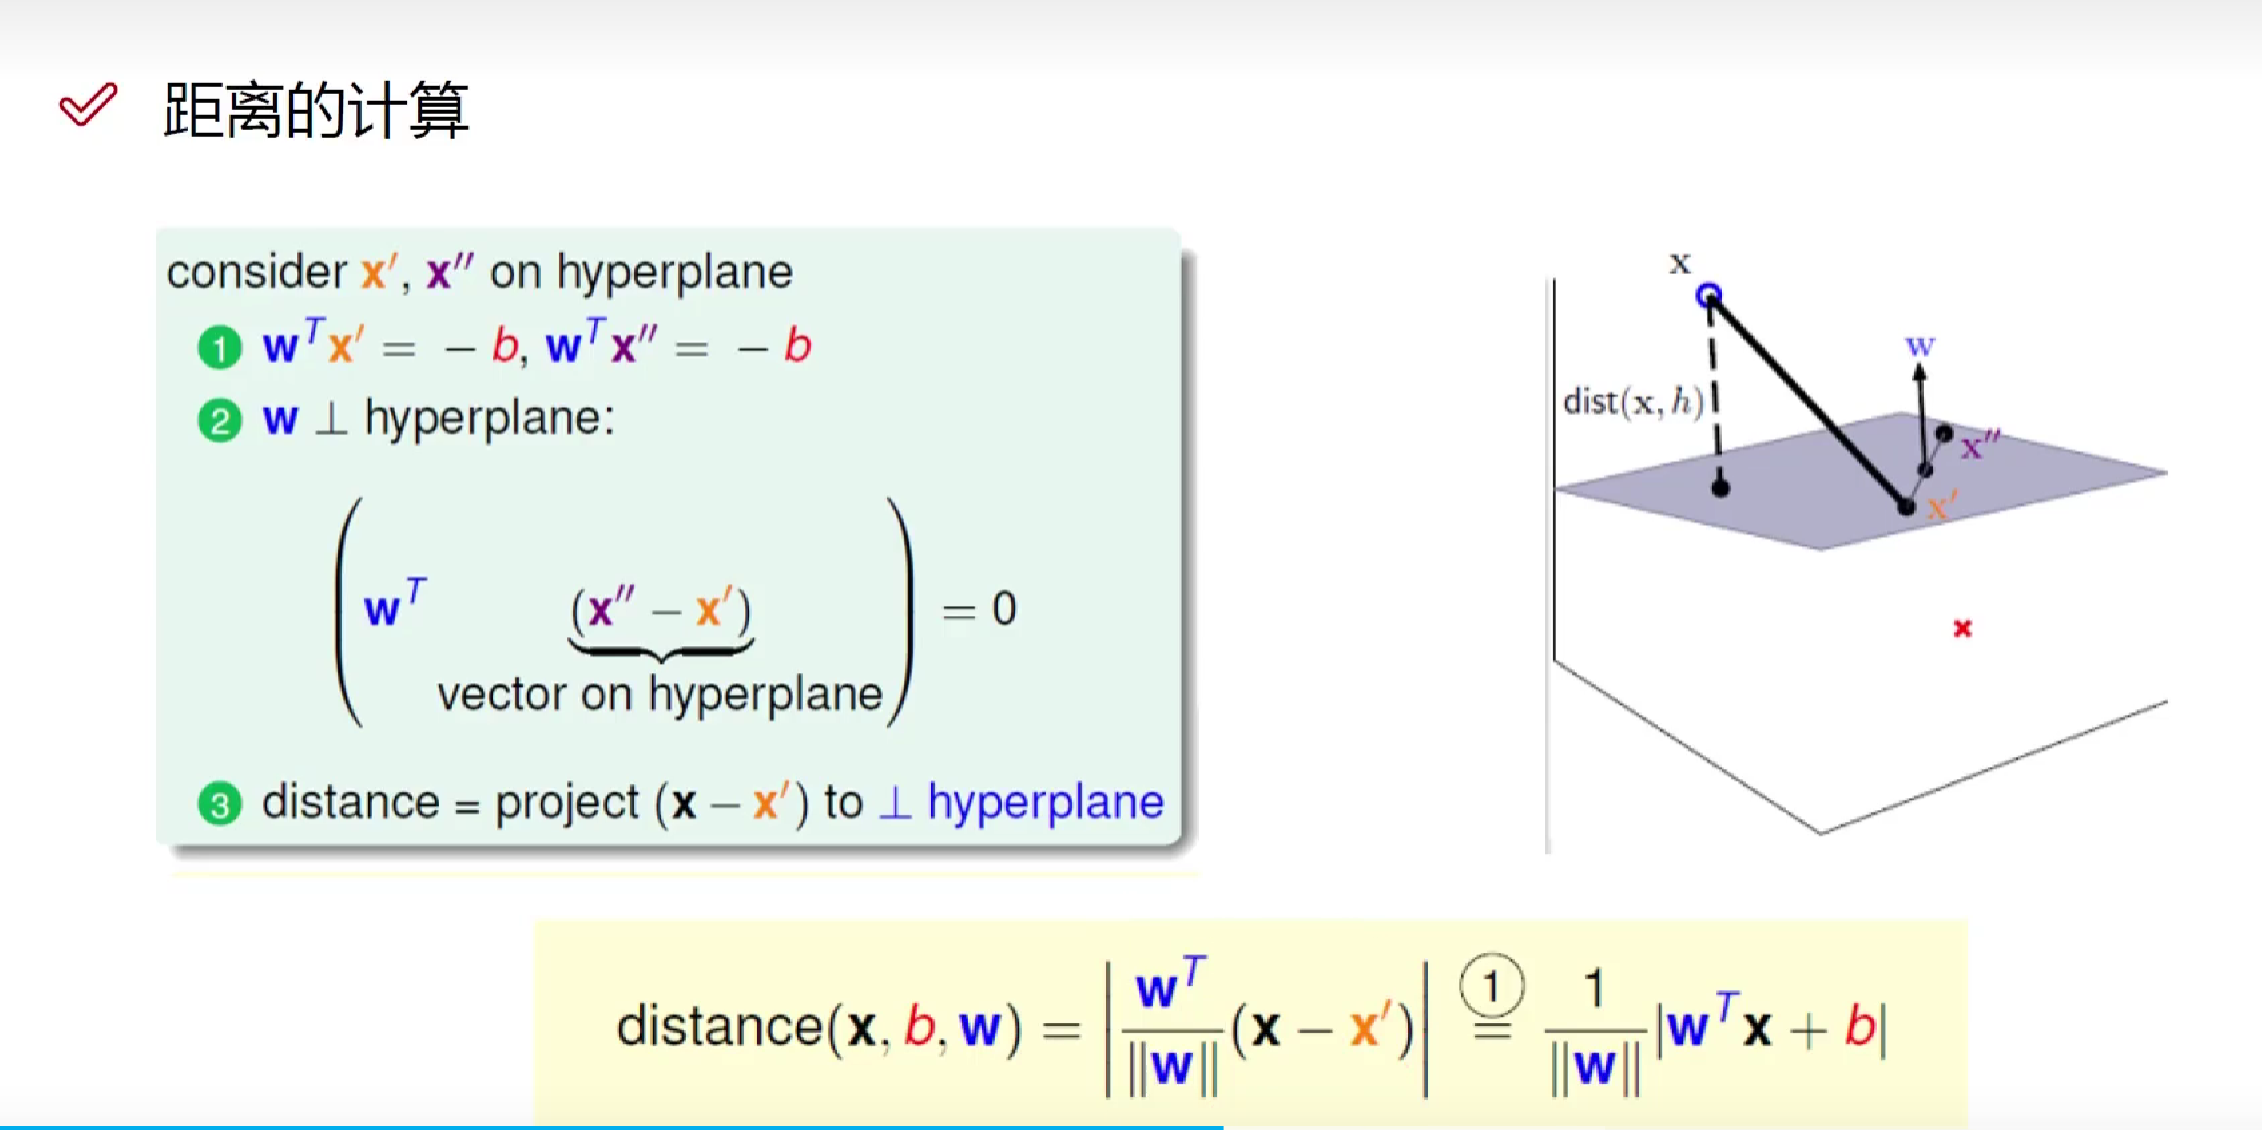

*   **目标函数 (Objective Function)**：
    $$ \min_{w, b} \frac{1}{2} \|w\|^2 $$
    *(解释：最小化法向量的模长平方，即最大化分类间隔)*

*   **约束条件 (Constraints)**：
    $$ y_i (w^T x_i + b) \ge 1, \quad \forall i=1, 2, ..., N $$
    *(解释：$y_i \in \{+1, -1\}$。这个条件强硬地要求：所有正样本必须在 $w^Tx+b \ge 1$ 的一侧，负样本必须在 $w^Tx+b \le -1$ 的一侧。**绝不允许任何一个样本处于间隔带内部或被分错**。)*
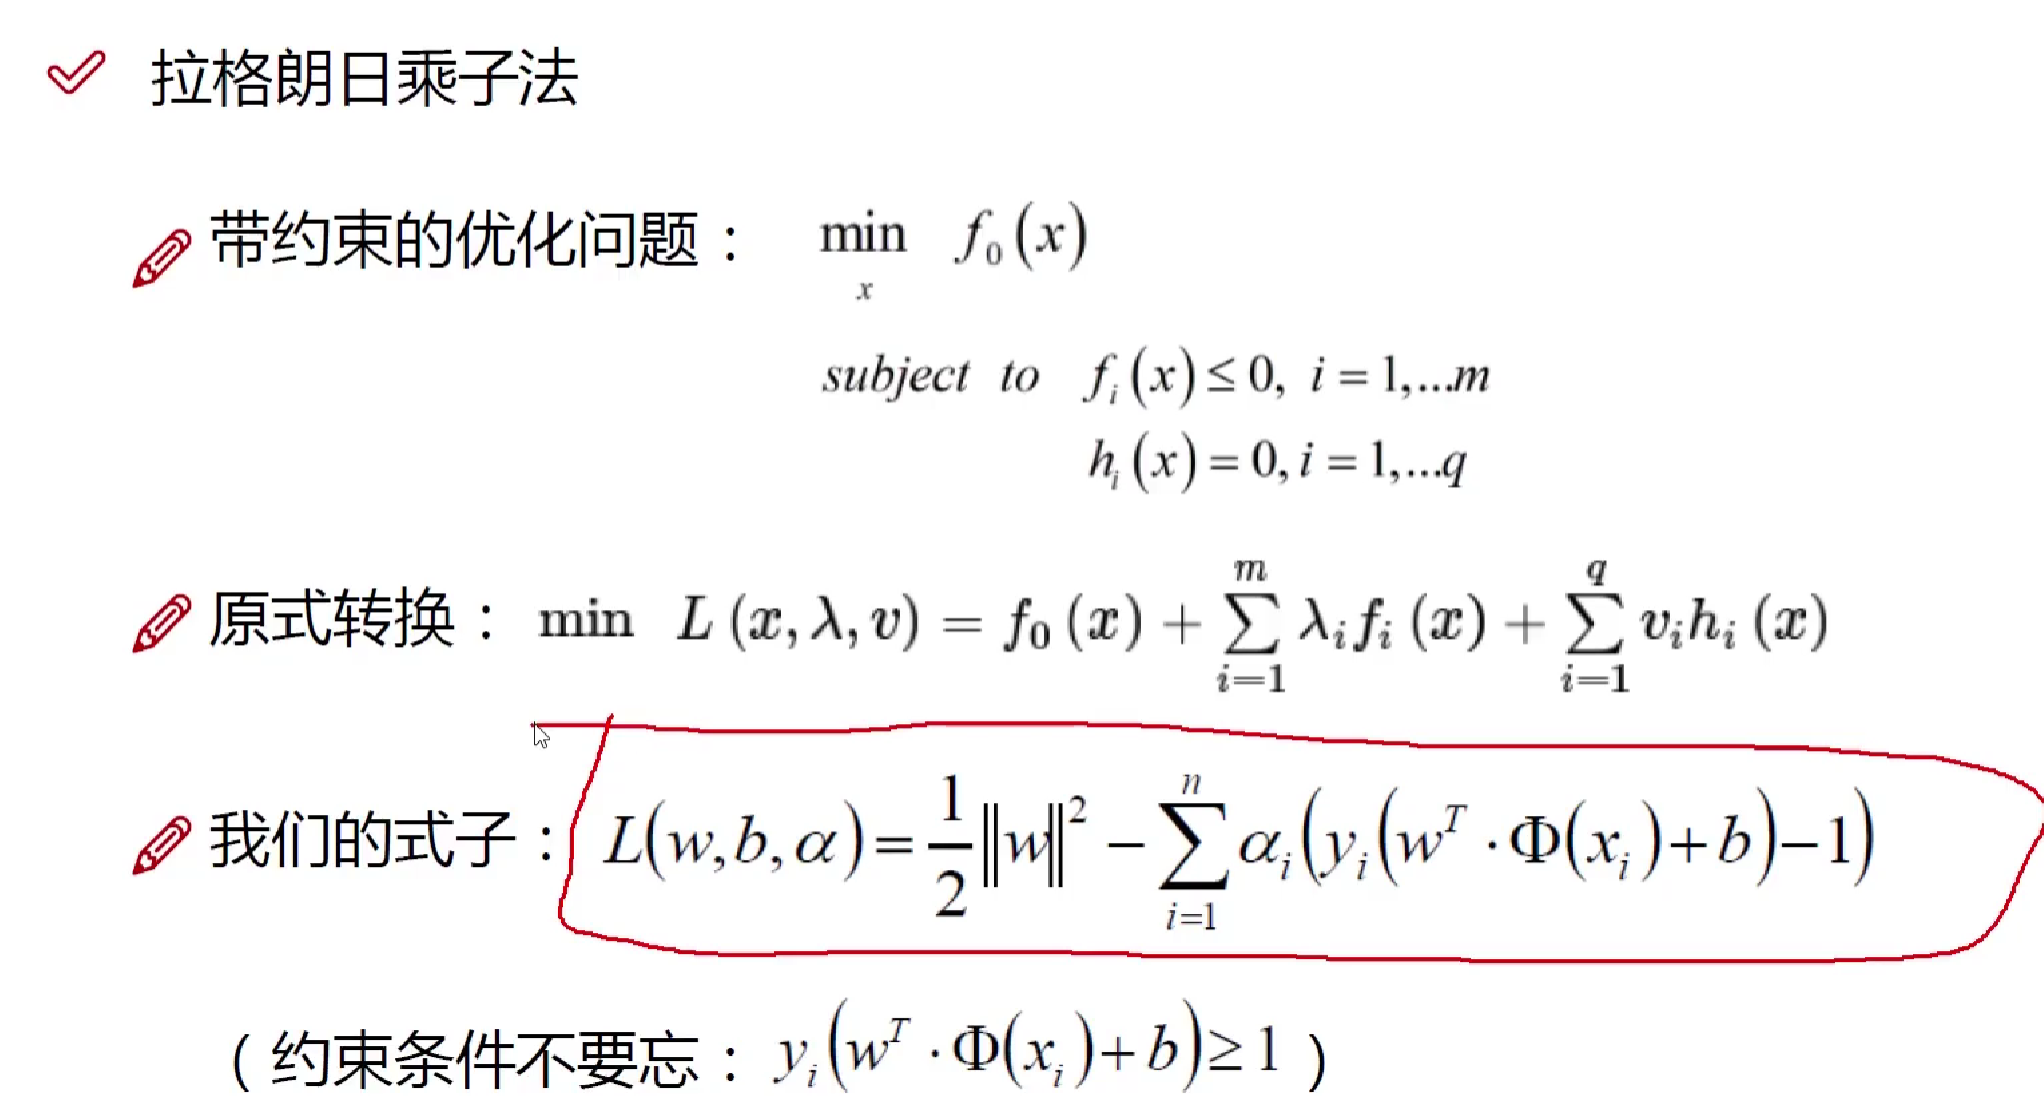
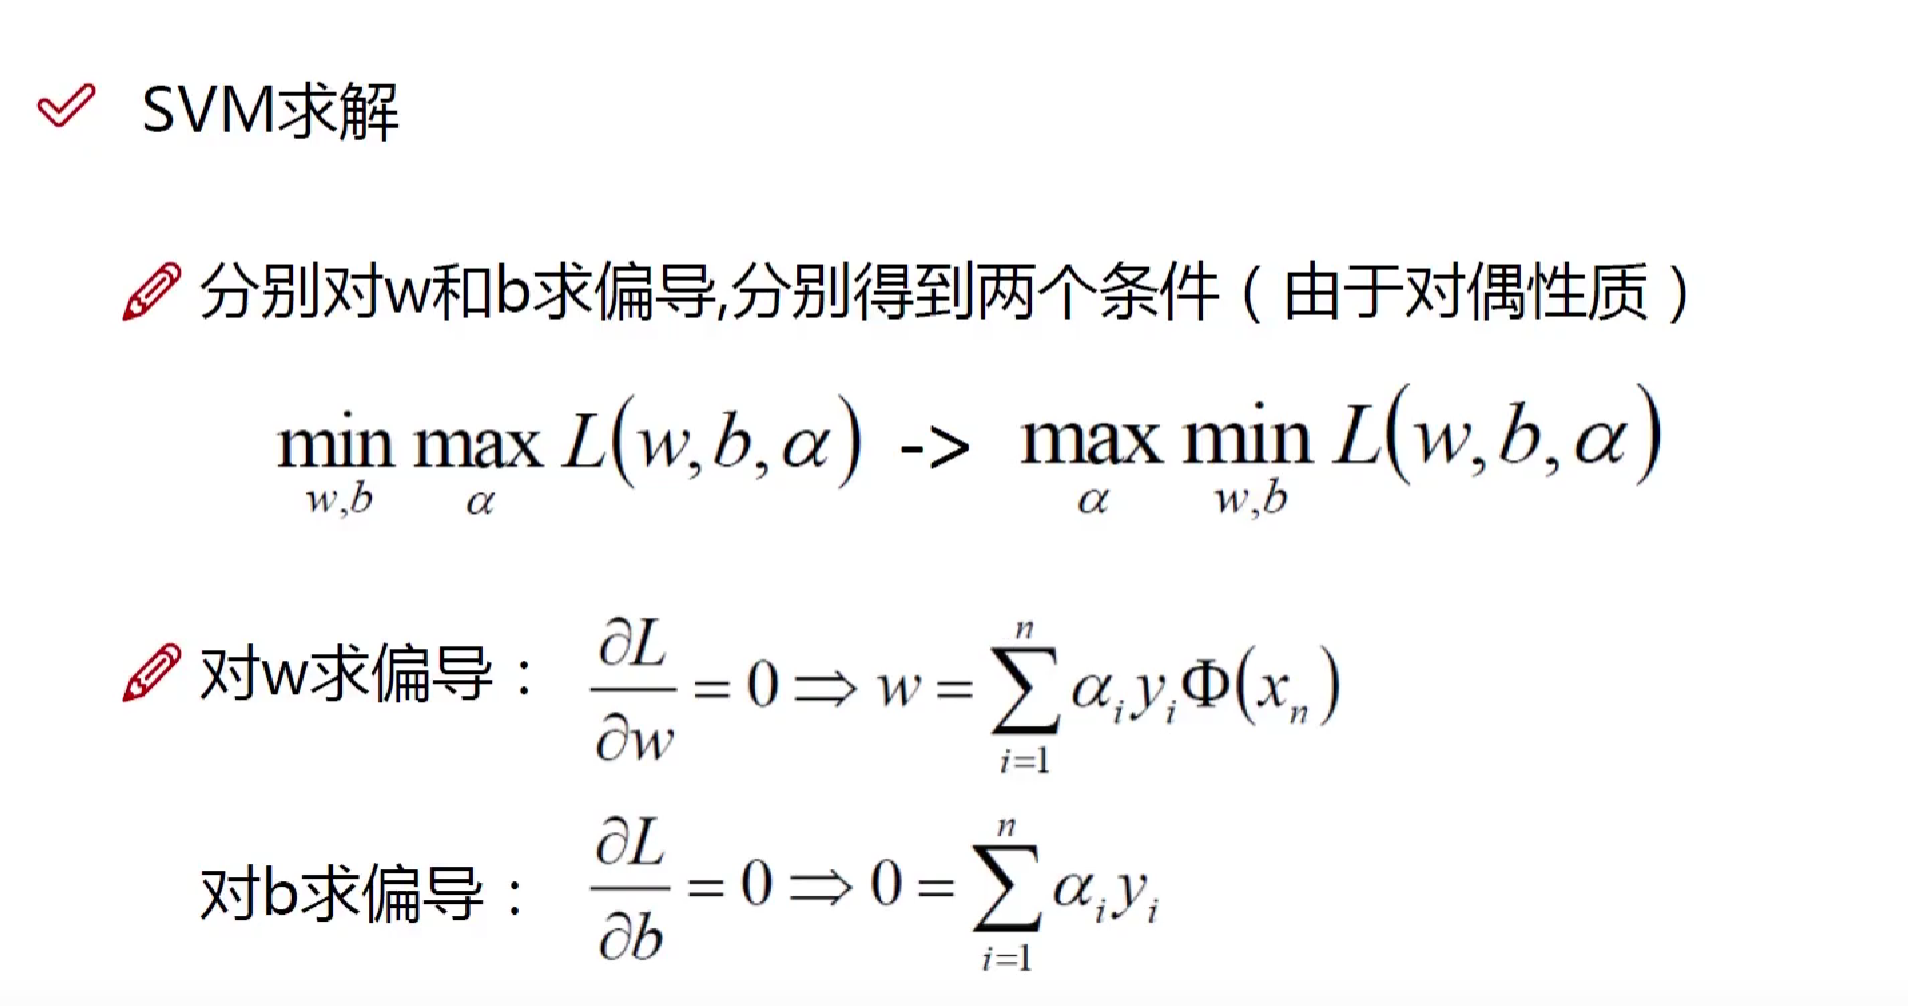

**局限性**：现实世界的数据很少是完美线性可分的。只要有一个异常值（Noise）跑到对面阵营，硬间隔 SVM 就会彻底崩溃（找不到解），或者为了迁就这一个异常值而使分类边界严重倾斜（过拟合）。

---

### 三、 阶段二：软间隔 SVM (Soft Margin) —— 拥抱现实的统计折中

**适用场景**：数据**大致线性可分**，但在边界附近存在互相穿插的噪声或异常值。
**核心逻辑**：既然做不到完美，我们就**允许部分样本分错或进入间隔带**，但我们要对这些“犯规”的样本施加惩罚。我们引入一个**松弛变量 $\xi_i$ (Slack Variable)**。

*   **目标函数 (Objective Function)**：
    $$ \min_{w, b, \xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^N \xi_i $$
    *(解释：前半部分依然是追求最大化间隔；后半部分是对犯规样本的惩罚。**$C$ 是惩罚系数（超参数）**：$C$ 越大，对错误越零容忍（逼近硬间隔）；$C$ 越小，越宽容，间隔带越宽。)*

*   **约束条件 (Constraints)**：
    1.  $$ y_i (w^T x_i + b) \ge 1 - \xi_i, \quad \forall i $$
        *(解释：分类阈值从绝对的 1 放宽到了 $1 - \xi_i$)*
    2.  $$ \xi_i \ge 0, \quad \forall i $$
        *(解释：松弛变量必须是非负数。如果点在正确位置，$\xi_i = 0$；如果越界，$\xi_i > 0$)*

**突破**：通过引入 $C$ 和 $\xi$，SVM 从“绝对死板的几何模型”变成了“具有强大鲁棒性的统计模型”，完美解决了异常值导致的过拟合问题。

---

### 四、 阶段三：核函数 SVM (Kernel Trick) —— 升维打击的非线性跨越

**适用场景**：数据**完全线性不可分**（例如环形分布、异或分布）。
**核心逻辑**：低维空间里揉在一起分不开的数据，如果我们把它们“抛”到高维甚至无穷维空间里，它们大概率就线性可分了。设映射函数为 $\phi(x)$。
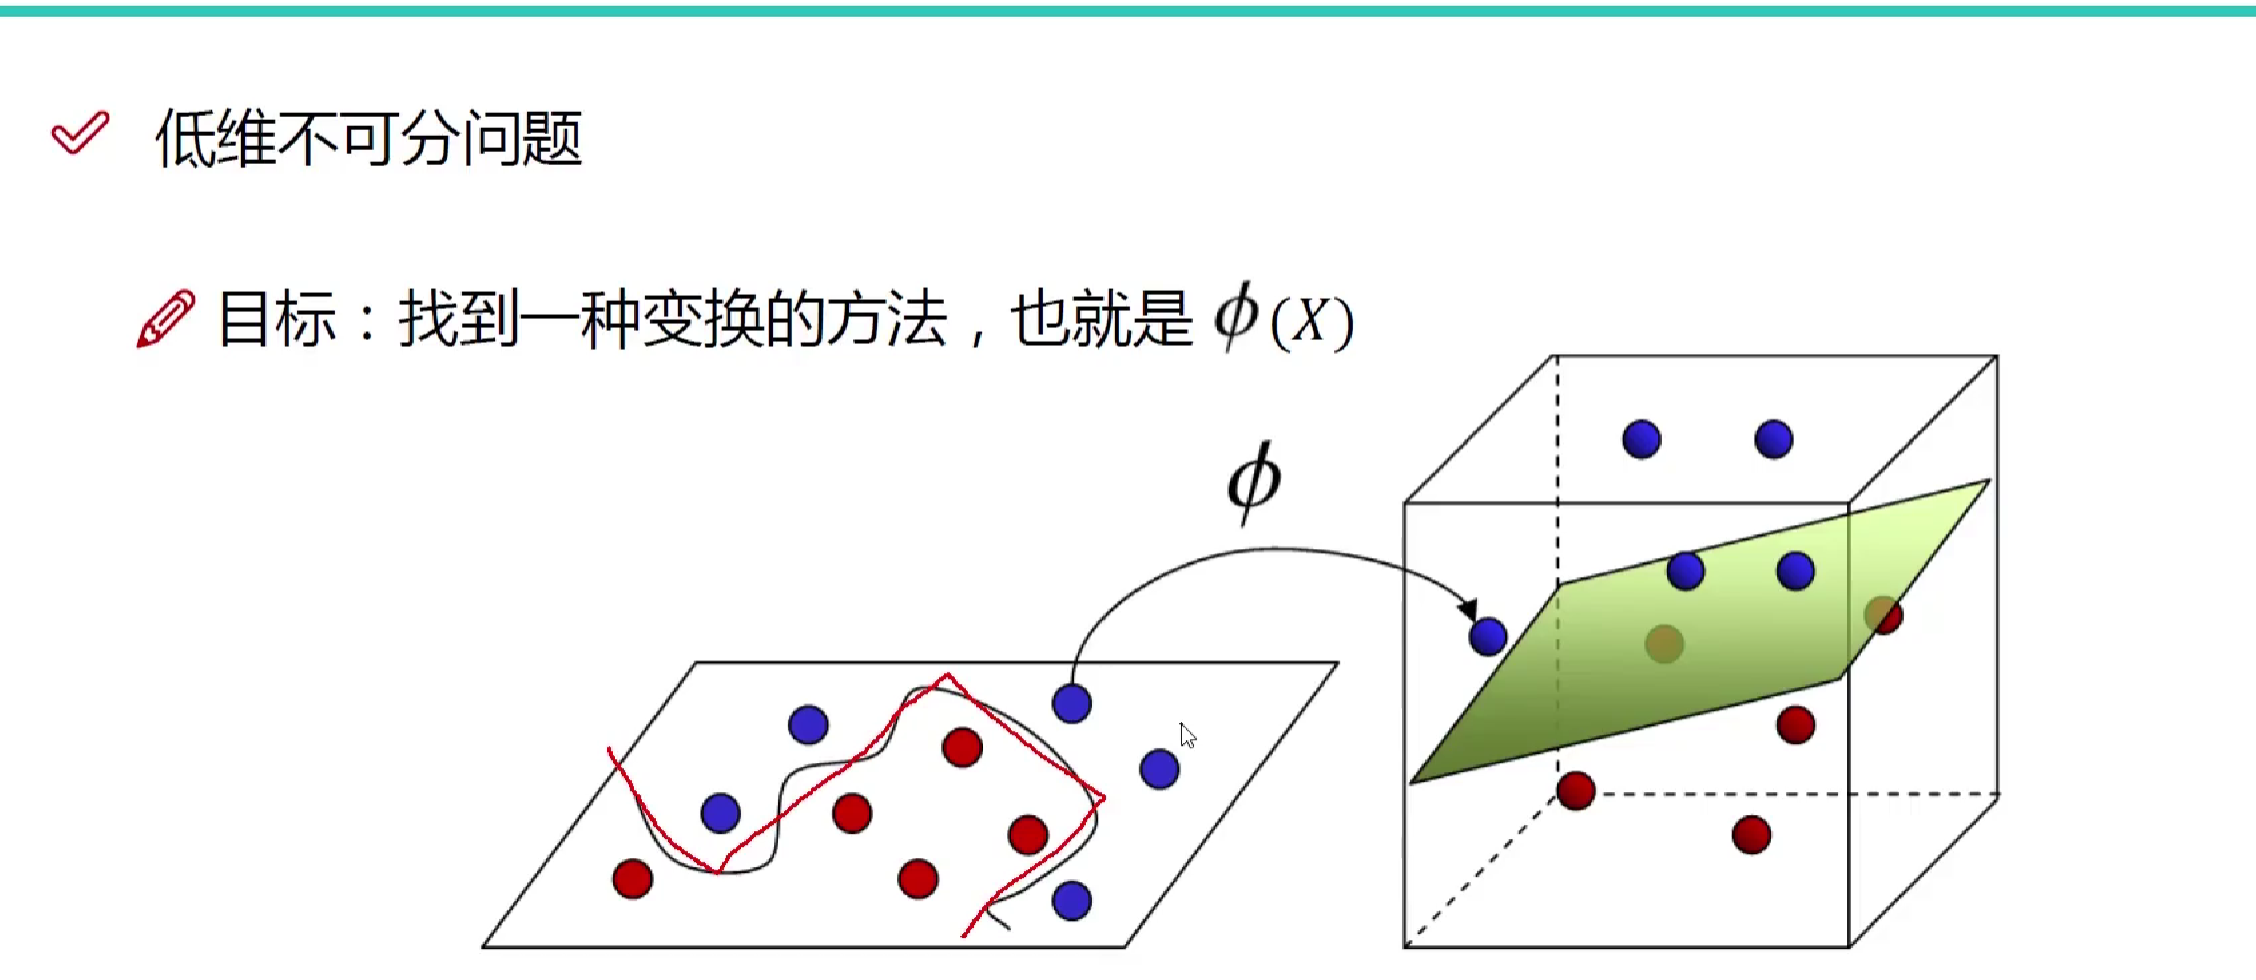

**为什么要用“核函数”？**
在解 SVM 的对偶问题（Dual Problem）时，数学家发现了一个奇迹：目标函数中所有的样本 $x$ 都不以独立形式存在，**而是全部以两个样本的内积（点积）形式 $x_i^T x_j$ 存在！** （
如果映射到高维，内积就变成了 $\phi(x_i)^T \phi(x_j)$。高维映射计算量极大，但**核函数 $K(x_i, x_j)$ 可以直接在低维空间计算出等价于高维空间内积的结果！** 这就是著名的“核技巧”（Kernel Trick）。

*   **对偶目标函数 (Dual Objective Function)**（引入核函数后）：
    $$ \max_{\alpha} \sum_{i=1}^N \alpha_i - \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j K(x_i, x_j) $$
    *(解释：$\alpha_i$ 是拉格朗日乘子。所有的原始特征 $x_i, x_j$ 均被包裹在核函数 $K(x_i, x_j)$ 中计算相似度。)*

*   **约束条件 (Constraints)**：
    1.  $$ \sum_{i=1}^N \alpha_i y_i = 0 $$
    2.  $$ 0 \le \alpha_i \le C, \quad \forall i $$
    *(解释：$\alpha_i > 0$ 的样本就是最终决定分类边界的**支持向量**。$C$ 依然控制着软间隔的宽容度。)*

#### 常见的三种相似度/核函数定义：
1.  **线性核**：$K(x_i, x_j) = x_i^T x_j$ (退化为普通软间隔 SVM，本质是计算余弦/点积相似度)。
2.  **多项式核**：$K(x_i, x_j) = (\gamma x_i^T x_j + r)^d$ (引入了特征之间的组合多项式相似度)。
3.  **高斯核 (RBF)**：$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$ (基于欧氏距离的相似度，隐式将数据映射到无穷维空间，是最强大的核函数)。

---

### 五、 系统的维度对比总结表

为了建立全局视角，我们将这三个维度系统地横向对比：

| 演化维度 | 数据前提假设 | 核心策略 | 目标函数核心成分 | 约束条件的变化 | 分类边界的形态 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **硬间隔 (Hard Margin)** | 完美线性可分 | 宁死不屈，找最宽的无菌隔离带 | $\min \frac{1}{2}\|w\|^2$ (仅最大化间隔) | $y_i(w^Tx_i+b) \ge \mathbf{1}$ (绝对服从) | 笔直的超平面，极其容易受异常值影响 |
| **软间隔 (Soft Margin)** | 大致线性可分 (含噪音) | 权衡利弊，允许部分错误但要罚款 | $\min \frac{1}{2}\|w\|^2 + \mathbf{C\sum\xi_i}$ (引入损失函数) | $y_i(w^Tx_i+b) \ge \mathbf{1-\xi_i}$ (引入松弛变量) | 笔直的超平面，但获得了极强的抗干扰鲁棒性 |
| **核函数 (Kernel)** | 完全线性不可分 | 升维打击，在看不见的高维做线性切分 | $\max \sum\alpha_i - \frac{1}{2}\sum\alpha_i\alpha_jy_iy_j \mathbf{K(x_i,x_j)}$ | $0 \le \alpha_i \le \mathbf{C}$ (对偶空间的截断) | 在原始空间表现为**高度扭曲的非线性曲面** |

### 结语与思想关联
**硬间隔与软间隔，是在寻找最完美的“分类边界”；而核函数，是在重新定义数据之间的“相似性”。**
当我们在 SVM 中选择高斯核时，实际上我们是在告诉模型：“不要用原始特征的点积来评估这两个样本有多像，请用它们在无穷维空间的距离投影来评估”。这就是数学工具在机器学习中最为优雅的融合。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles

# 设置全局中文字体和清晰度（针对 Jupyter）
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows用黑体
plt.rcParams['axes.unicode_minus'] = False

def plot_svm_boundary(model, X, y, title="SVM Decision Boundary"):
    """
    绘制 SVM 决策边界、间隔带以及支持向量
    """
    # 绘制数据点
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn', edgecolors='k')
    
    # 获取当前坐标轴的限制
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 创建网格来评估模型
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # 获取决策函数的值（距离超平面的距离）
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # 绘制决策边界和间隔带 (Z=0 是边界，Z=-1 和 1 是间隔边界)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # 标出支持向量 (用大圆圈圈出来)
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
               linewidth=2, facecolors='none', edgecolors='blue', label='支持向量')
    
    plt.title(title, fontsize=14)
    plt.legend(loc='upper right')

[[ 6.44294752 -9.34456701]
 [ 8.23773823 -2.87401089]
 [ 6.69273952 -9.77485628]
 [ 8.84077768 -3.61834006]
 [ 7.74859907 -3.03988418]]
[1 0 1 0 0]


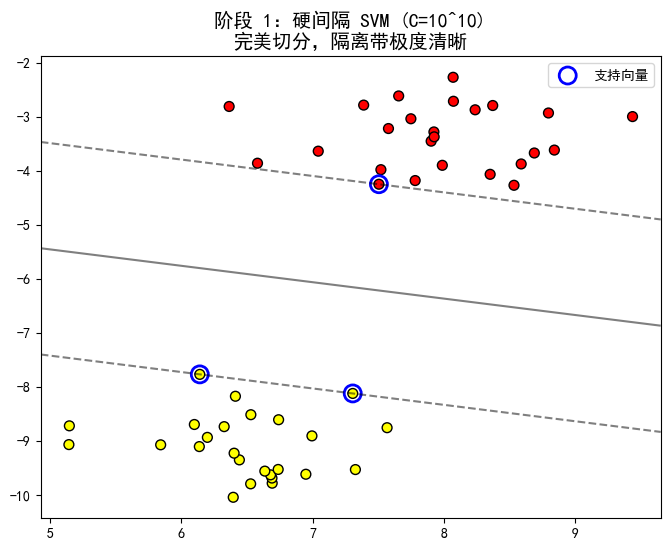

In [5]:
# 1. 生成【完美线性可分】的数据
X_hard, y_hard = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=0.6)
print(X_hard[:5, ])
print(y_hard[:5, ])

# 2. 拟合硬间隔 SVM (极大化 C)
svm_hard = SVC(kernel='linear', C=1e10)
svm_hard.fit(X_hard, y_hard)

# 3. 绘图
plt.figure(figsize=(8, 6))
plot_svm_boundary(svm_hard, X_hard, y_hard, title="阶段 1：硬间隔 SVM (C=10^10)\n完美切分，隔离带极度清晰")
plt.show()

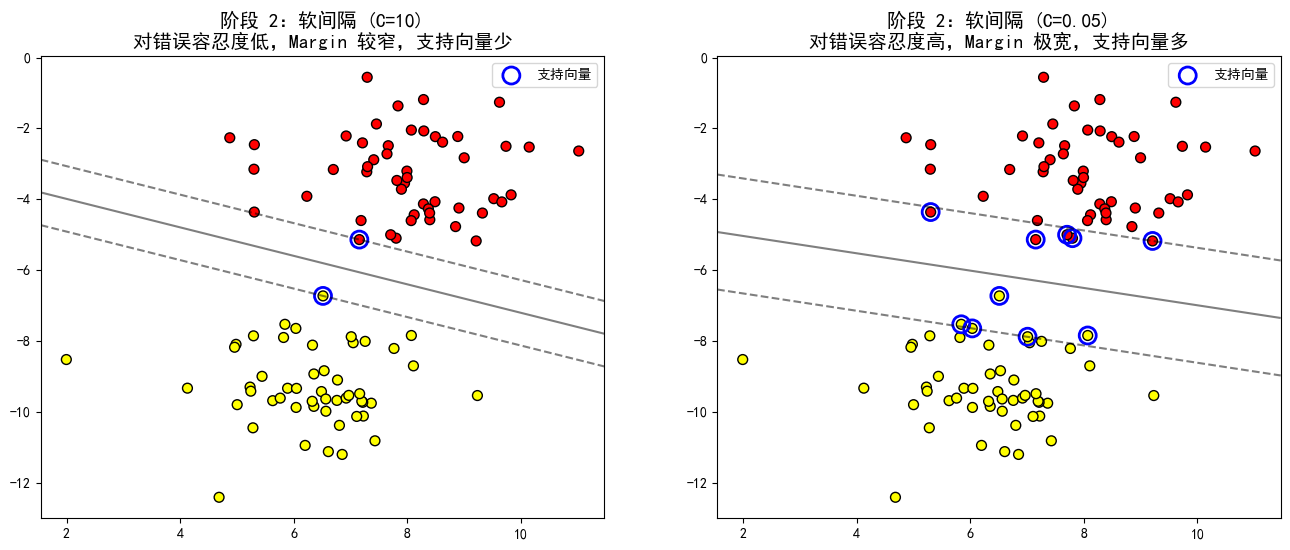

In [6]:
# 1. 生成【带有噪音、互相穿插】的数据
X_soft, y_soft = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)

# 2. 对比两个不同 C 值的软间隔 SVM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 模型 A：C 很大（严苛，像硬间隔妥协）
svm_soft_strict = SVC(kernel='linear', C=10)
svm_soft_strict.fit(X_soft, y_soft)
plt.sca(axes[0])
plot_svm_boundary(svm_soft_strict, X_soft, y_soft, title="阶段 2：软间隔 (C=10)\n对错误容忍度低，Margin 较窄，支持向量少")

# 模型 B：C 很小（宽容，大局观）
svm_soft_tolerant = SVC(kernel='linear', C=0.05)
svm_soft_tolerant.fit(X_soft, y_soft)
plt.sca(axes[1])
plot_svm_boundary(svm_soft_tolerant, X_soft, y_soft, title="阶段 2：软间隔 (C=0.05)\n对错误容忍度高，Margin 极宽，支持向量多")

plt.show()

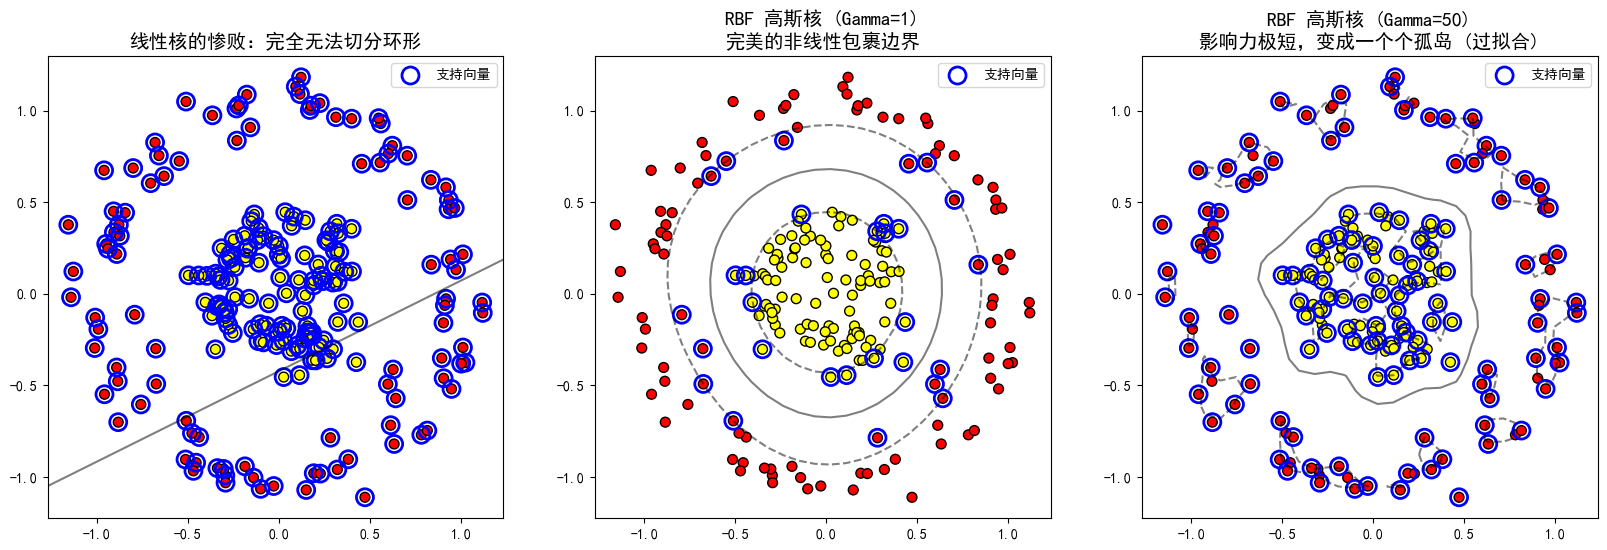

In [7]:
# 1. 生成【完全非线性：环形数据】
X_kernel, y_kernel = make_circles(n_samples=200, factor=0.3, noise=0.1, random_state=42)

# 2. 试错：如果硬用线性核会怎样？
svm_wrong = SVC(kernel='linear')
svm_wrong.fit(X_kernel, y_kernel)

# 3. 升维打击：使用 RBF 高斯核，并对比 gamma
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 图 A：线性核的惨败
plt.sca(axes[0])
plot_svm_boundary(svm_wrong, X_kernel, y_kernel, title="线性核的惨败：完全无法切分环形")

# 图 B：RBF核，合适的 Gamma
svm_rbf_good = SVC(kernel='rbf', C=1, gamma=1)  # gamma=1
svm_rbf_good.fit(X_kernel, y_kernel)
plt.sca(axes[1])
plot_svm_boundary(svm_rbf_good, X_kernel, y_kernel, title="RBF 高斯核 (Gamma=1)\n完美的非线性包裹边界")

# 图 C：RBF核，极大的 Gamma (过拟合)
svm_rbf_overfit = SVC(kernel='rbf', C=1, gamma=50) # gamma=50
svm_rbf_overfit.fit(X_kernel, y_kernel)
plt.sca(axes[2])
plot_svm_boundary(svm_rbf_overfit, X_kernel, y_kernel, title="RBF 高斯核 (Gamma=50)\n影响力极短，变成一个个孤岛 (过拟合)")

plt.show()